In [6]:
import pandas as pd
from tqdm import tqdm
import h5py
from utilities import *

In [15]:
df = pd.read_csv('data/metadata.csv')
X = np.load('data/X_100hz.npy')
df.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


# Data Preparation

In [16]:
df['scp_codes'].value_counts()[10:20]

scp_codes
{'IRBBB': 100.0, 'SR': 0.0}                 167
{'NORM': 100.0}                             163
{'NORM': 80.0, 'SBRAD': 0.0}                151
{'NST_': 100.0, 'SR': 0.0}                  145
{'NORM': 80.0, 'STACH': 0.0}                128
{'NORM': 100.0, 'SBRAD': 0.0}               124
{'NDT': 100.0, 'NT_': 0.0, 'SR': 0.0}       123
{'NORM': 100.0, 'SARRH': 0.0}               118
{'LVH': 100.0, 'ISC_': 100.0, 'SR': 0.0}    114
{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}    114
Name: count, dtype: int64

In [ ]:
# X_processed = clean(X, bandpass_range=[0.5, 45], normalize=False)
X_processed = np.load('data/X_processed.npy')

In [ ]:
greatest_val=0

for d in df.scp_codes:
    for k, v in eval(d).items():
        greatest_val = max(greatest_val, v)

greatest_val

100.0

In [ ]:
agg_df = pd.read_csv('data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def aggregate_diagnostic(y_dict):
    y_dict = eval(y_dict)
    new_dict = {}

    for sc in superclasses:
        new_dict[sc]=0

    for key, val in y_dict.items():
        if key in agg_df.index:
            sc = agg_df.loc[key]['diagnostic_class']
            new_dict[sc]=max(new_dict[sc], val/100)

    lst = []
    for sc in superclasses:
        lst.append(new_dict[sc])
    return lst


In [ ]:
df.scp_codes.apply(aggregate_diagnostic)

0        [1.0, 0, 0, 0, 0]
1        [0.8, 0, 0, 0, 0]
2        [1.0, 0, 0, 0, 0]
3        [1.0, 0, 0, 0, 0]
4        [1.0, 0, 0, 0, 0]
               ...        
21794    [0, 0, 1.0, 0, 0]
21795    [1.0, 0, 0, 0, 0]
21796    [0, 0, 0.5, 0, 0]
21797    [1.0, 0, 0, 0, 0]
21798    [1.0, 0, 0, 0, 0]
Name: scp_codes, Length: 21799, dtype: object

In [ ]:
df['diagnostic_superclass'] = df.scp_codes.apply(aggregate_diagnostic)

In [ ]:
Y = np.array(df['diagnostic_superclass'].to_list())

train_mask = df['strat_fold'] <= 8
val_mask = df['strat_fold'] == 9
test_mask = df['strat_fold'] == 10

X_train, Y_train = X_processed[train_mask], Y[train_mask]
X_val, Y_val     = X_processed[val_mask], Y[val_mask]
X_test, Y_test   = X_processed[test_mask], Y[test_mask]

del X_processed

In [ ]:
# save as separate .h5 files
for X, Y, name in [(X_train, Y_train, 'train'), (X_val, Y_val, 'val'), (X_test, Y_test, 'test')]:
    with h5py.File(f'data/{name}.h5', 'w') as f:
        dset = f.create_dataset('features', shape=(X.shape[0], 12, 45, 219), dtype='float32') #(batch size, channels, hight, width)
        labels = f.create_dataset('labels', shape=Y.shape, dtype='float32')

        for i in tqdm(range(X.shape[0]), desc=f'processing: X_{name}'):
            patient_tensor = np.zeros((12, 45, 219), dtype='float32')

            for lead in range(12):
                patient_tensor[lead] = generate_ecg_spectrogram(X[i][:, lead])

            dset[i]=patient_tensor
            labels[i] = Y[i]

processing: X_test: 100%|██████████| 2198/2198 [00:41<00:00, 53.31it/s]


# Model Training

In [7]:
import torch
import torch.nn as nn
from torch import optim

class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, hidden_size=128):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=4, padding='same')
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=13, kernel_size=2, padding='same')
        self.conv3 = nn.Conv2d(in_channels=13, out_channels=13, kernel_size=2, padding='same')

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.5)
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1755, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        # first layer
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # second layer
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # third layer
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        # final layers
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
#        x = self.sigmoid(x) BCEWithLogitsLoss

        return x
    
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
cnn = CNN(in_channels=12, num_classes=5).to(device)
print(cnn)

cuda
CNN(
  (conv1): Conv2d(12, 8, kernel_size=(4, 4), stride=(1, 1), padding=same)
  (conv2): Conv2d(8, 13, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (conv3): Conv2d(13, 13, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1755, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


In [4]:
# test
cnn.forward(torch.zeros(1, 12, 45, 219).to(device))

/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/torch/nn/modules/conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv2d(


/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/torch/nn/modules/conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv2d(


tensor([[-0.0620, -0.0555,  0.0289, -0.0782, -0.0504]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [8]:
from torch.utils.data import Dataset, DataLoader
class ECGH5Dataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path

        with h5py.File(self.file_path, 'r') as f:
            self.length = f['features'].shape[0]

        self.file = None

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.file_path, 'r')

        x = self.file['features'][idx]
        y = self.file['labels'][idx]

        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

train_dataset = ECGH5Dataset('data/train.h5')
val_dataset = ECGH5Dataset('data/val.h5')
test_dataset = ECGH5Dataset('data/test.h5')

kwargs = {'batch_size': 128, 'num_workers': 6, 'pin_memory': True, 'prefetch_factor': 2}
train_loader = DataLoader(train_dataset, shuffle=True, **kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **kwargs)

In [8]:
# model training
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(cnn.parameters(), lr=0.001, weight_decay=0.01)

In [10]:
train_loss = []
val_losses = []

num_epochs = 100
for epoch in range(num_epochs):
    cnn.train()
    tot_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for data, targets in pbar:
        data = data.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        scores = cnn(data)
        loss = criterion(scores, targets)

        loss.backward()
        optimizer.step()

        tot_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
        
    train_loss.append(tot_loss / len(train_loader))

    cnn.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        for data, targets in val_pbar:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            scores = cnn(data)
            loss = criterion(scores, targets)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))
    
    if ((epoch+1)%10)==0:
        print(f"End of Epoch {epoch+1} | Train Loss: {train_loss[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}\n\n")
        torch.save(cnn.state_dict(), f'model_weights/paper_model_epoch_{epoch+1}.pth')

Epoch 1/100 [Train]:  96%|█████████▋| 132/137 [00:15<00:00,  8.68it/s, loss=0.483]


KeyboardInterrupt: 

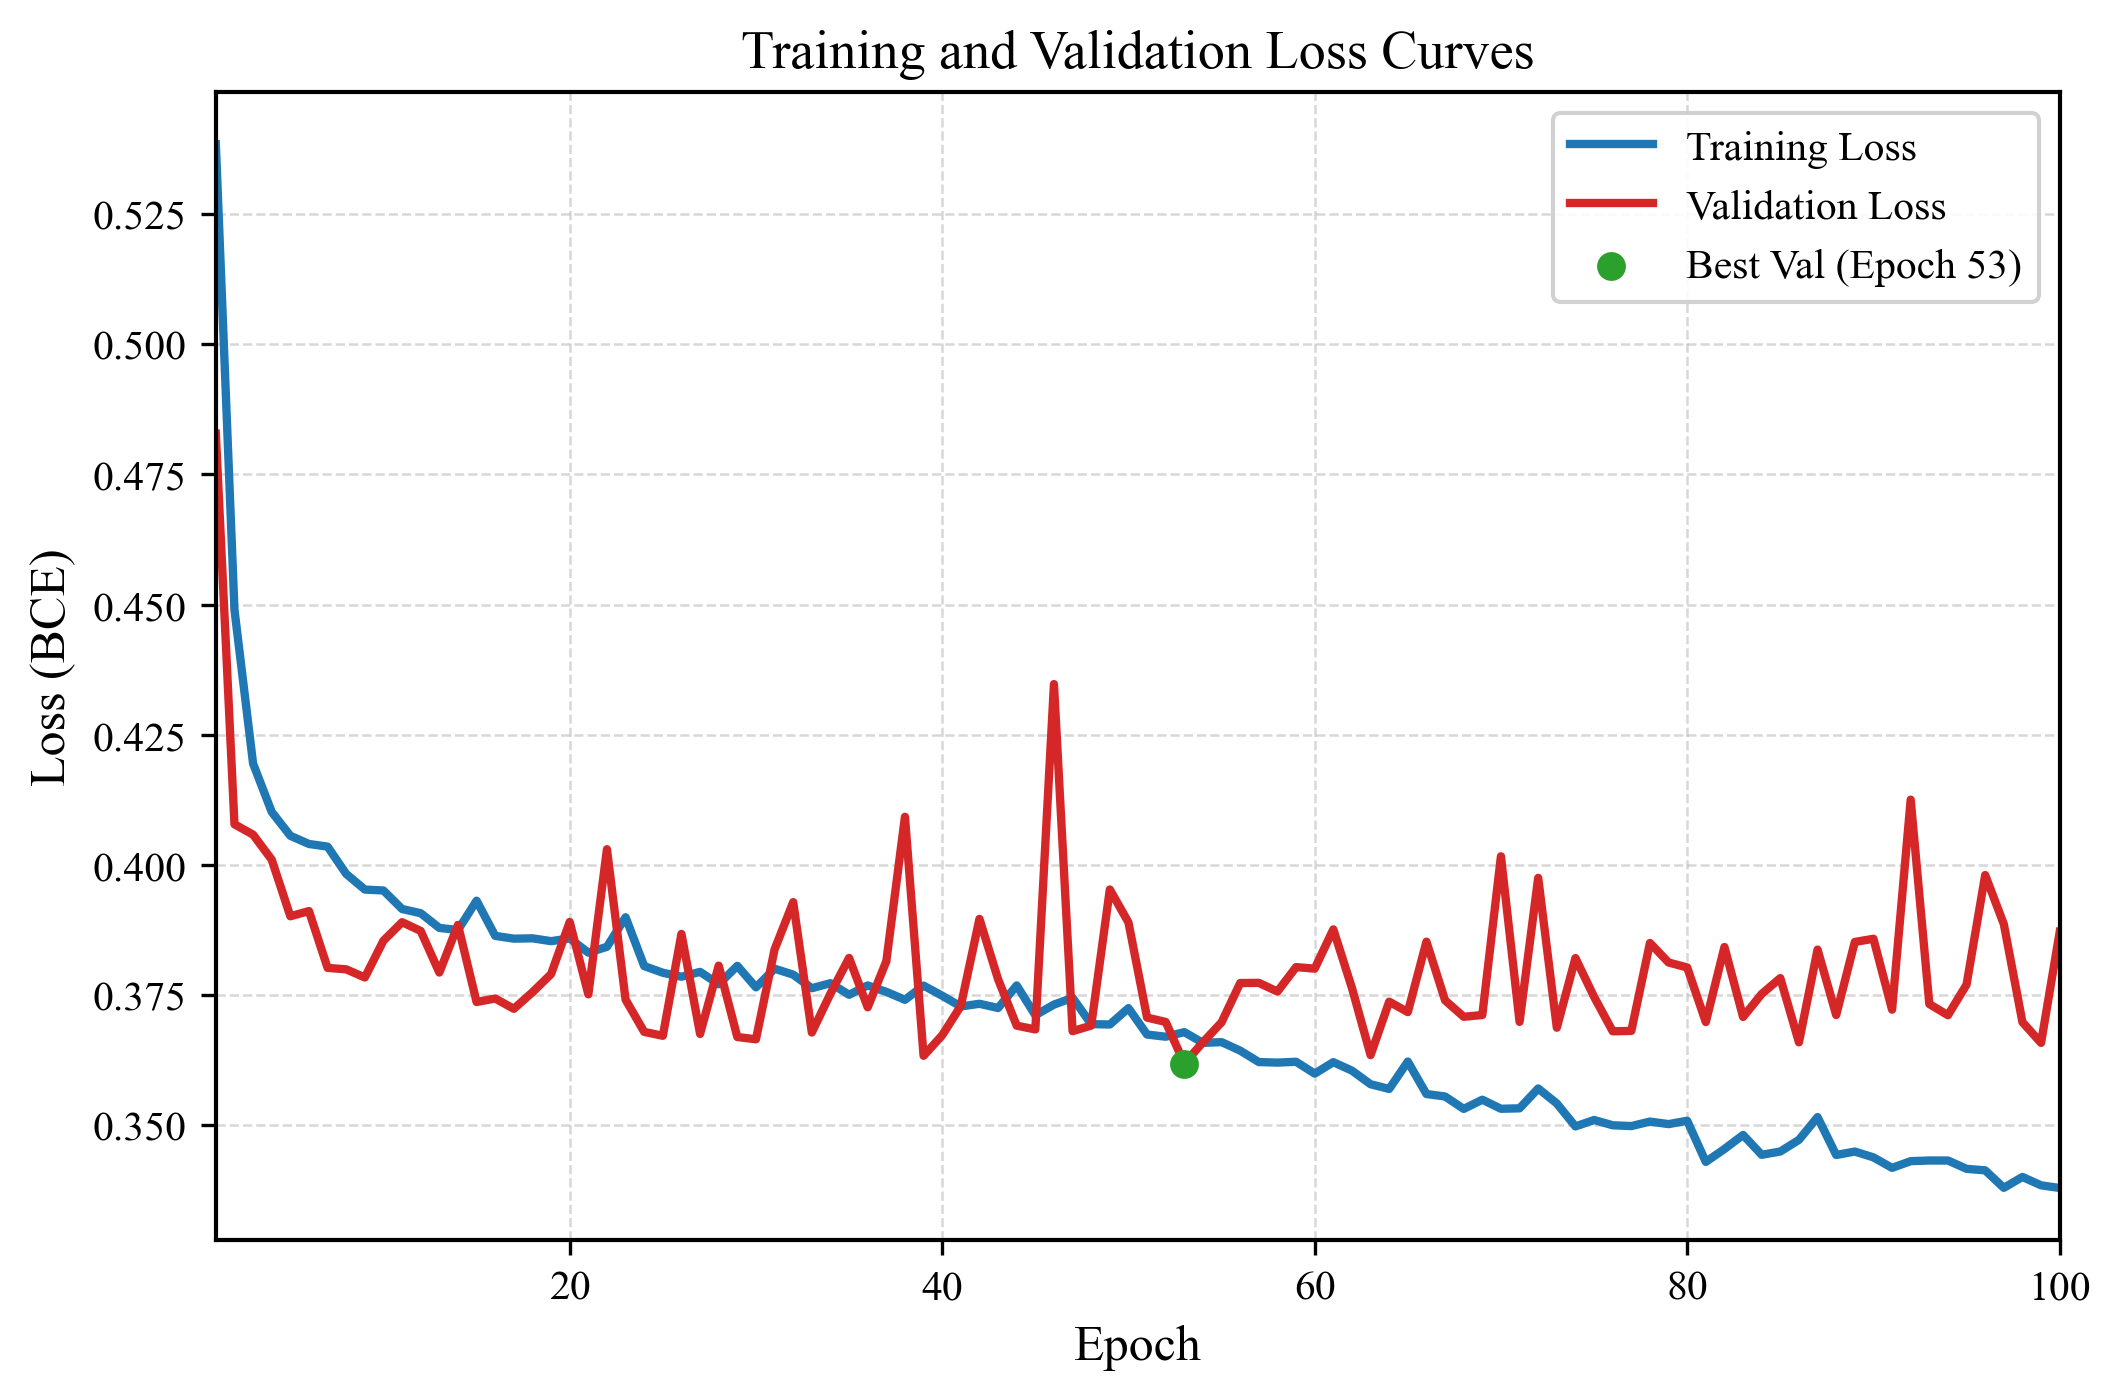

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Publication-style settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs = np.arange(1, len(train_loss) + 1)
train_arr = np.asarray(train_loss, dtype=float)
val_arr = np.asarray(val_losses, dtype=float)

if len(train_arr) != len(val_arr):
    raise ValueError(f"Length mismatch: train_loss={len(train_arr)}, val_losses={len(val_arr)}")

best_epoch = int(np.argmin(val_arr)) + 1
best_val = float(np.min(val_arr))

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=300)

ax.plot(
    epochs,
    train_arr,
    color="#1f77b4",
    linewidth=2.0,
    label="Training Loss",
)
ax.plot(
    epochs,
    val_arr,
    color="#d62728",
    linewidth=2.0,
    label="Validation Loss",
)

ax.scatter(
    [best_epoch],
    [best_val],
    color="#2ca02c",
    s=35,
    zorder=5,
    label=f"Best Val (Epoch {best_epoch})",
)

ax.set_title("Training and Validation Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (BCE)")
ax.set_xlim(1, len(epochs))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=True, facecolor="white", framealpha=0.9)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

fig.tight_layout()
fig.savefig("loss_curves_3_BCE_AdamW-2.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
x, y = train_dataset.__getitem__(1463)

x = x.reshape(1, *x.shape).to(device)

y_pred = cnn.forward(x).cpu().detach().numpy()
y_true = y.numpy()
print(np.round(y_pred, 1), '\n', y_true)

[[ 0.2 -1.7 -2.5 -2.1 -3.8]] 
 [0.8 0.  0.  0.  0. ]


In [ ]:
np.array(y_pred>=0.5, dtype='uint8')

array([[1, 0, 0, 0, 0]], dtype=uint8)

# Explanation

In [12]:
from lime import lime_image
import shap

/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# load final model
final_cnn = CNN(in_channels=12, num_classes=5).to(device)
final_cnn.load_state_dict(torch.load('model_weights/paper_model_epoch_100.pth'))

/tmp/ipykernel_41755/3452700080.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_cnn.load_state_dict(torch.load('model_weights/paper_model_epoch_100.pth'))


<All keys matched successfully>


Sample 1/5 | Dataset idx=9879 | Loss=0.0018
True classes (target>0.5): ['CD']
Pred classes (prob>0.5)  : ['CD']
Target vector            : [0. 0. 0. 1. 0.]
Probability vector       : [6.000e-04 9.000e-04 0.000e+00 9.963e-01 3.700e-03]


100%|██████████| 1000/1000 [00:03<00:00, 295.19it/s]


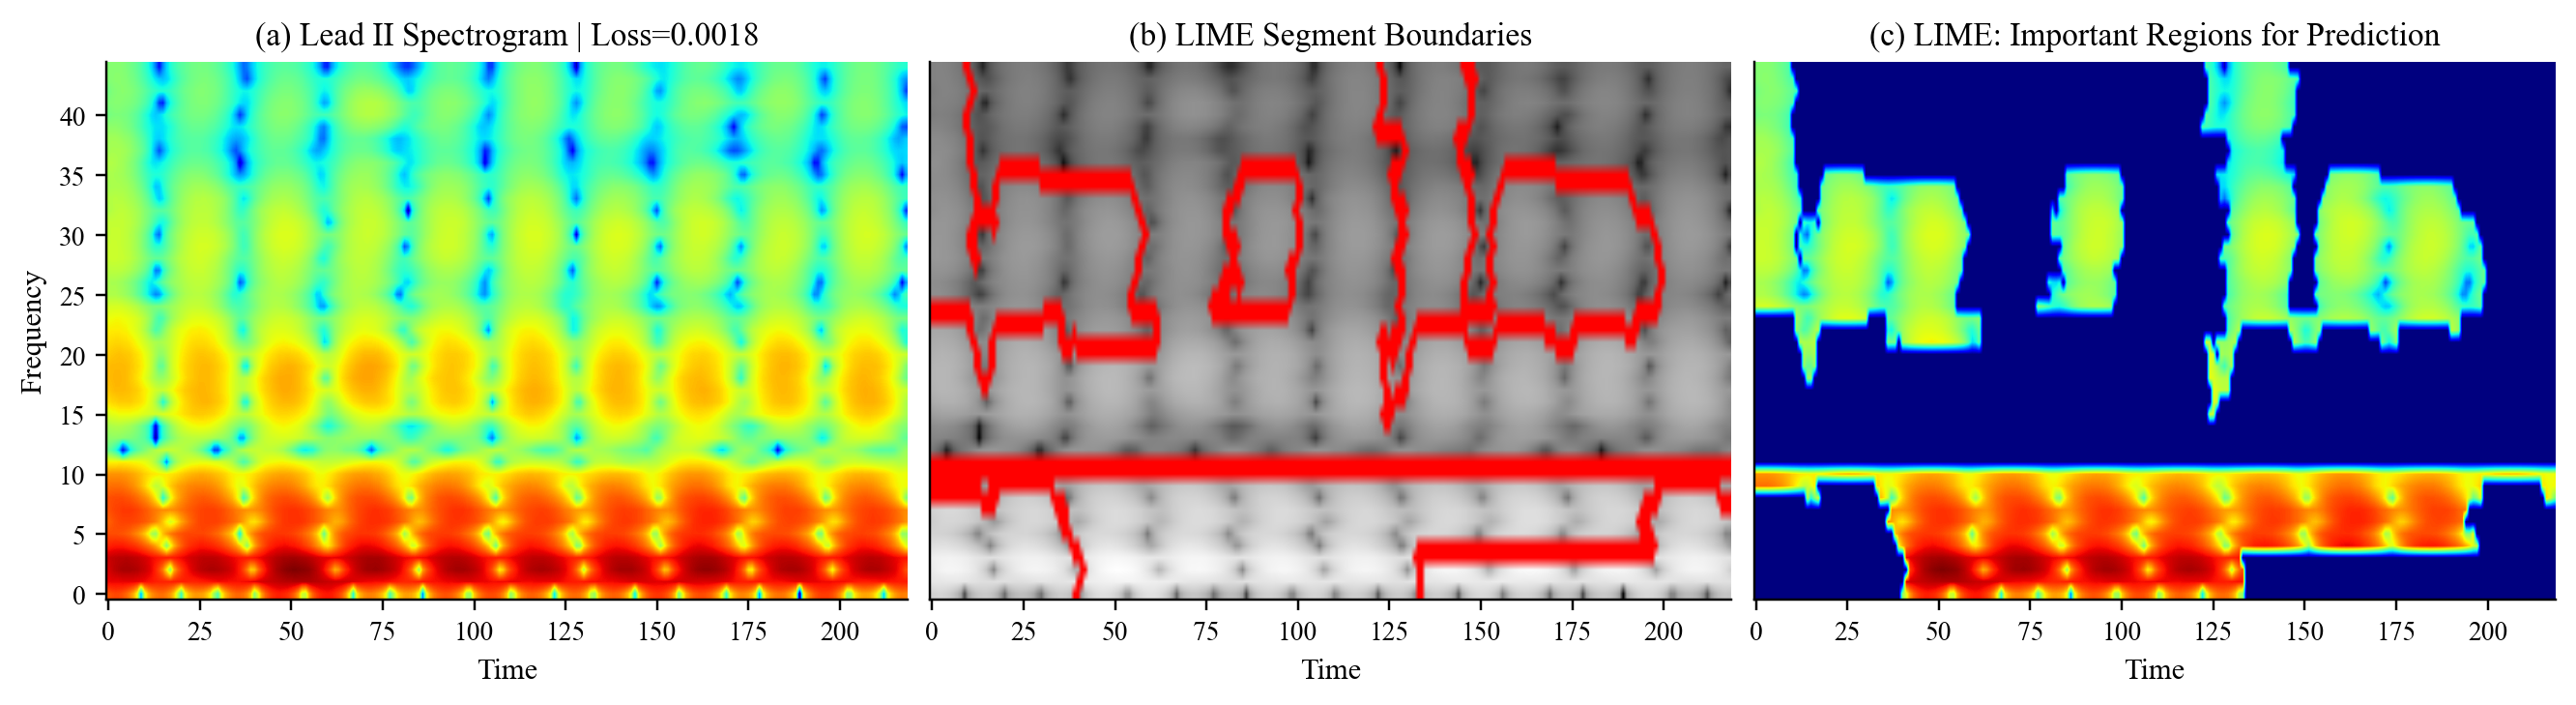


Sample 2/5 | Dataset idx=12758 | Loss=0.3191
True classes (target>0.5): ['STTC']
Pred classes (prob>0.5)  : ['STTC']
Target vector            : [0.  0.5 1.  0.  0. ]
Probability vector       : [0.0039 0.3319 0.8473 0.1945 0.3664]


100%|██████████| 1000/1000 [00:06<00:00, 150.76it/s]


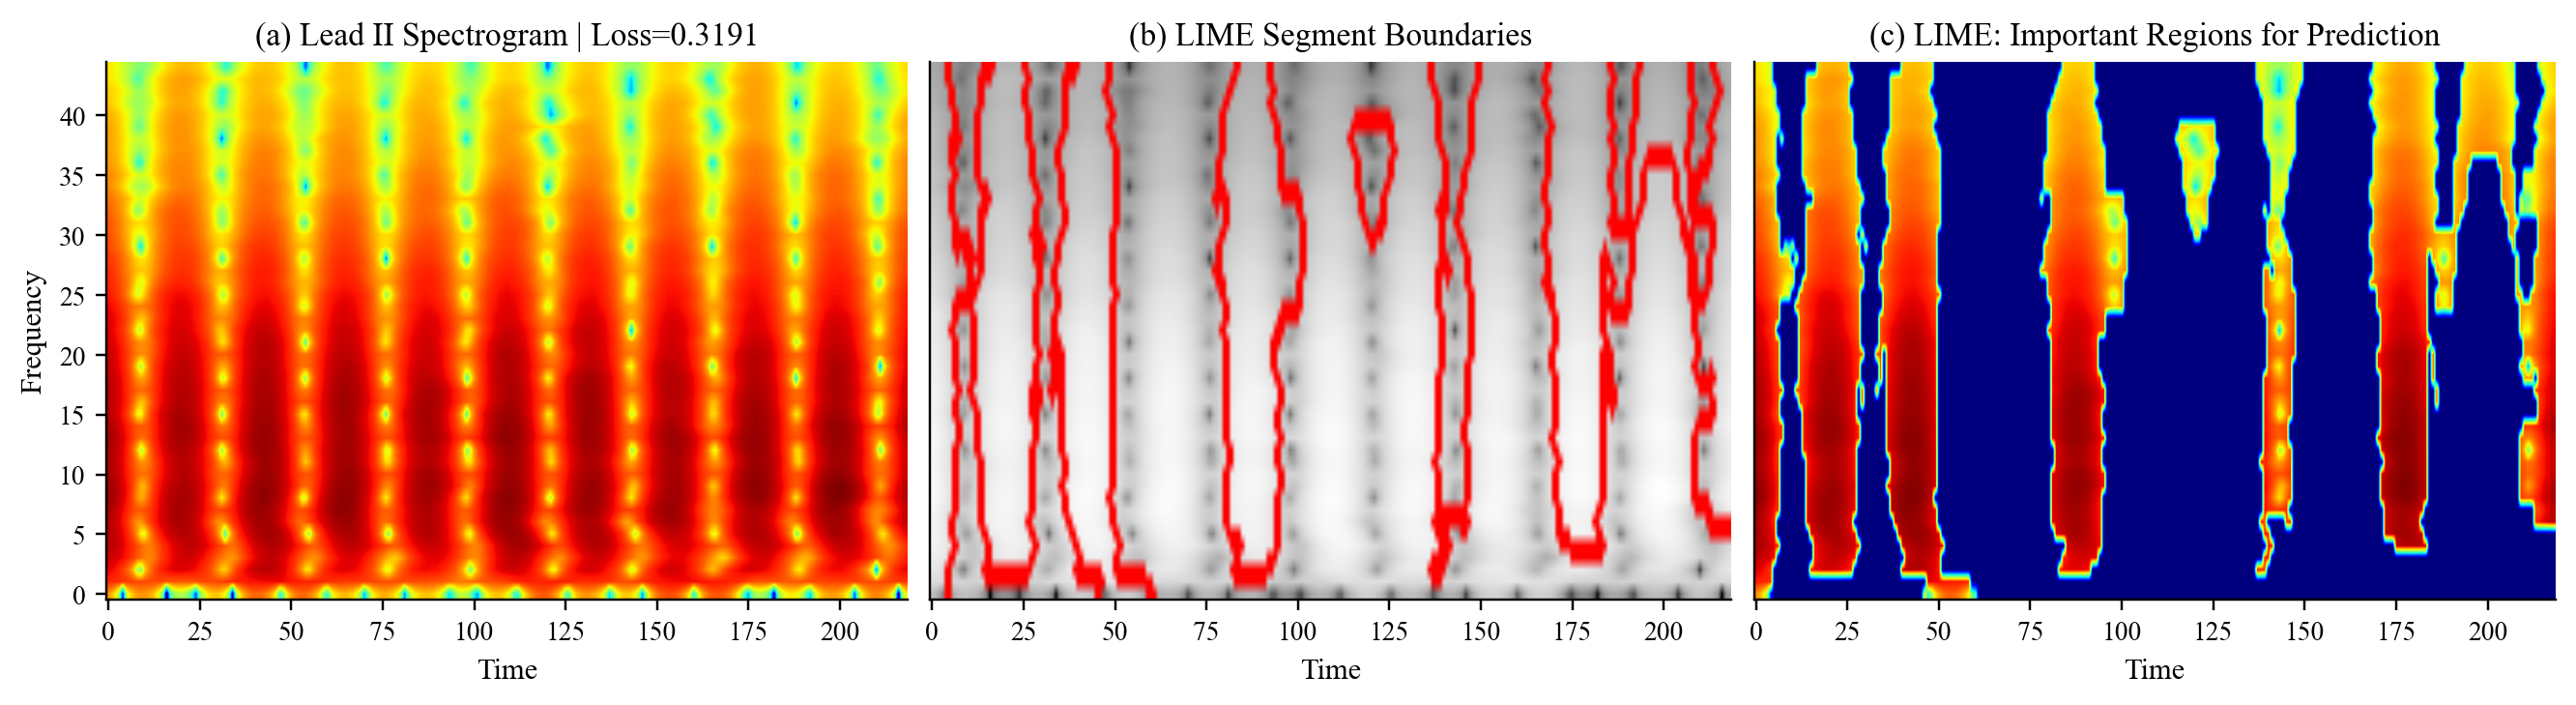


Sample 3/5 | Dataset idx=16134 | Loss=0.4384
True classes (target>0.5): ['STTC']
Pred classes (prob>0.5)  : ['None']
Target vector            : [0.   0.   1.   0.   0.35]
Probability vector       : [0.1621 0.2294 0.4896 0.2227 0.1388]


100%|██████████| 1000/1000 [00:08<00:00, 113.85it/s]


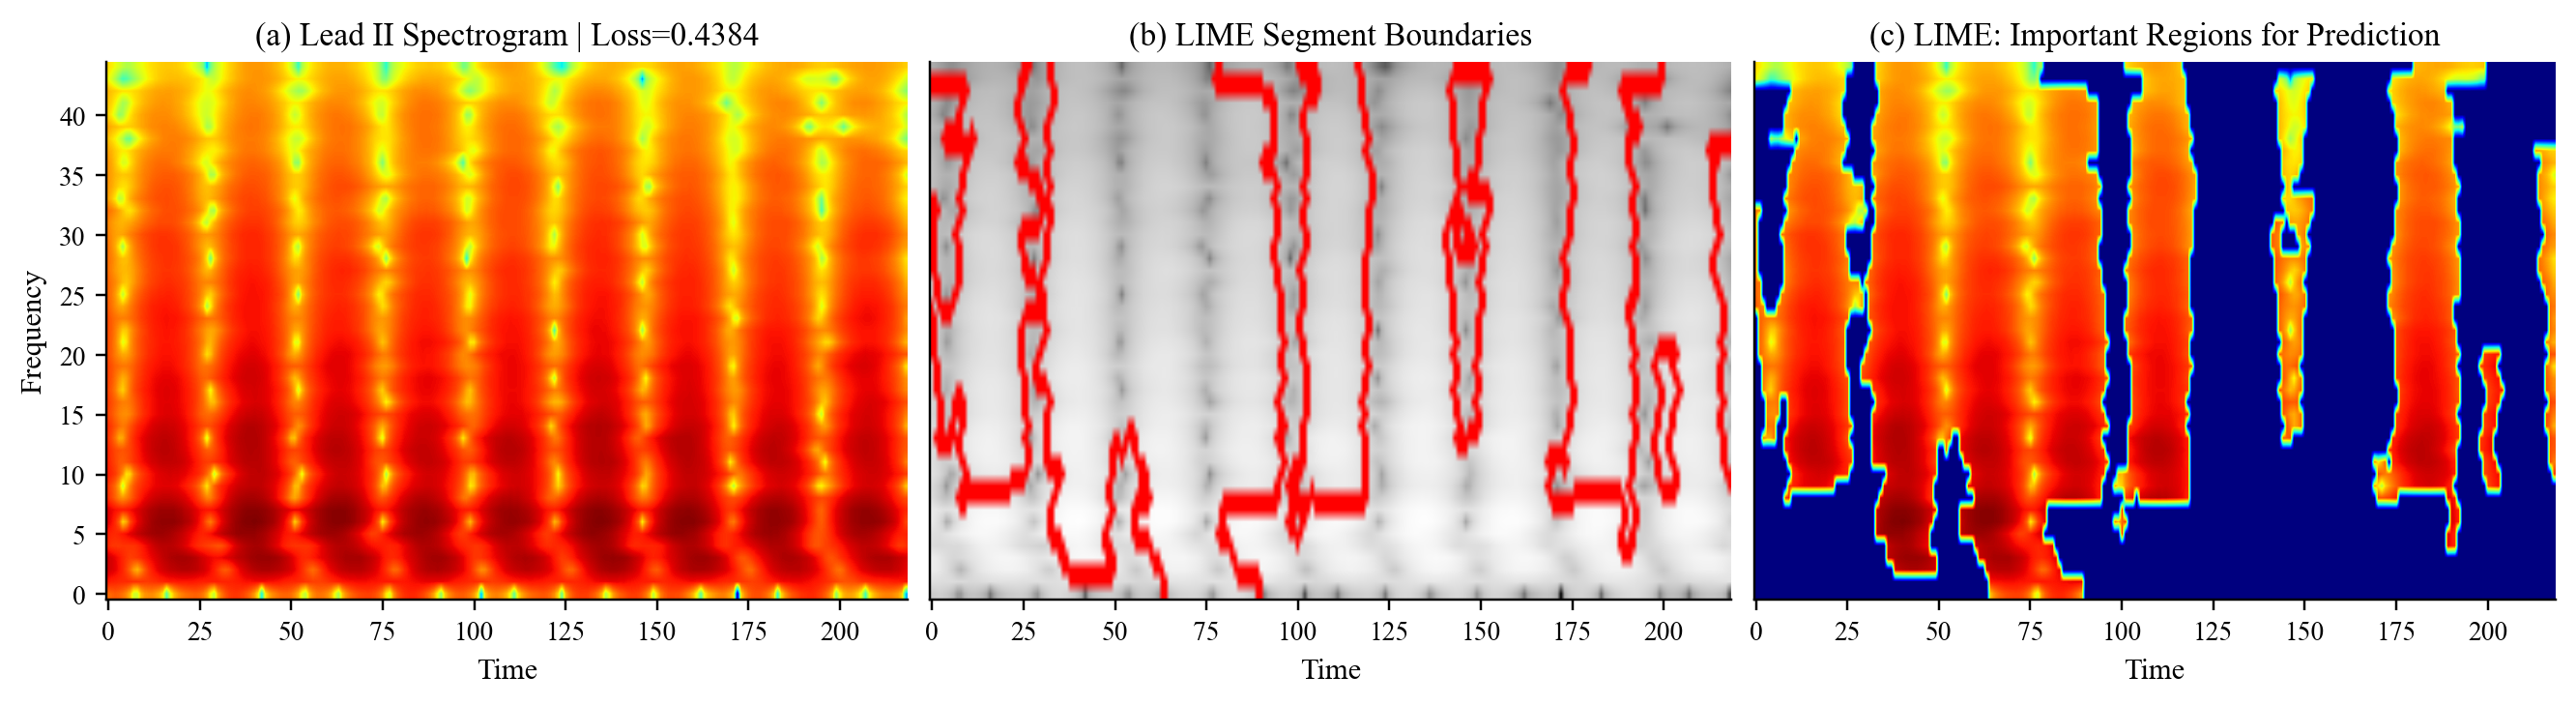


Sample 4/5 | Dataset idx=12531 | Loss=0.6050
True classes (target>0.5): ['HYP']
Pred classes (prob>0.5)  : ['STTC']
Target vector            : [0. 0. 0. 0. 1.]
Probability vector       : [0.005  0.2321 0.8336 0.1184 0.4332]


100%|██████████| 1000/1000 [00:13<00:00, 74.09it/s]


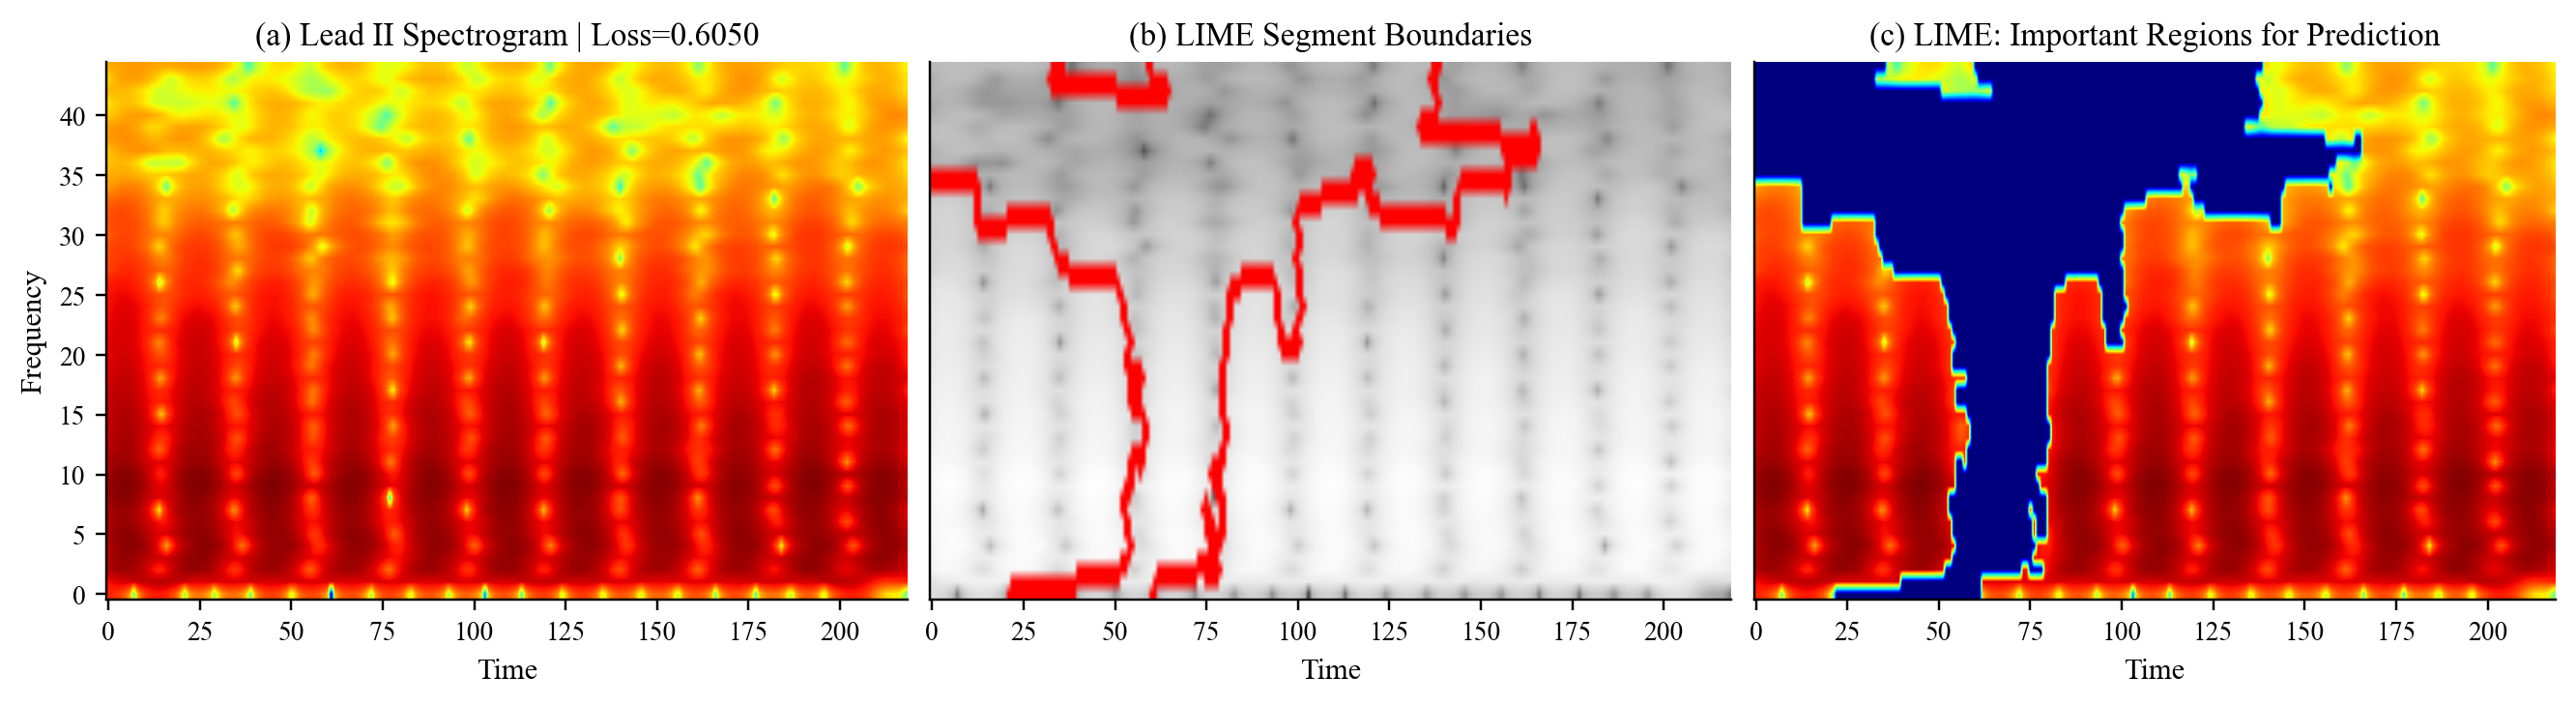


Sample 5/5 | Dataset idx=5813 | Loss=5.4914
True classes (target>0.5): ['NORM']
Pred classes (prob>0.5)  : ['CD']
Target vector            : [1. 0. 0. 0. 0.]
Probability vector       : [0.000e+00 9.000e-04 0.000e+00 9.979e-01 9.200e-03]


100%|██████████| 1000/1000 [00:15<00:00, 64.75it/s]


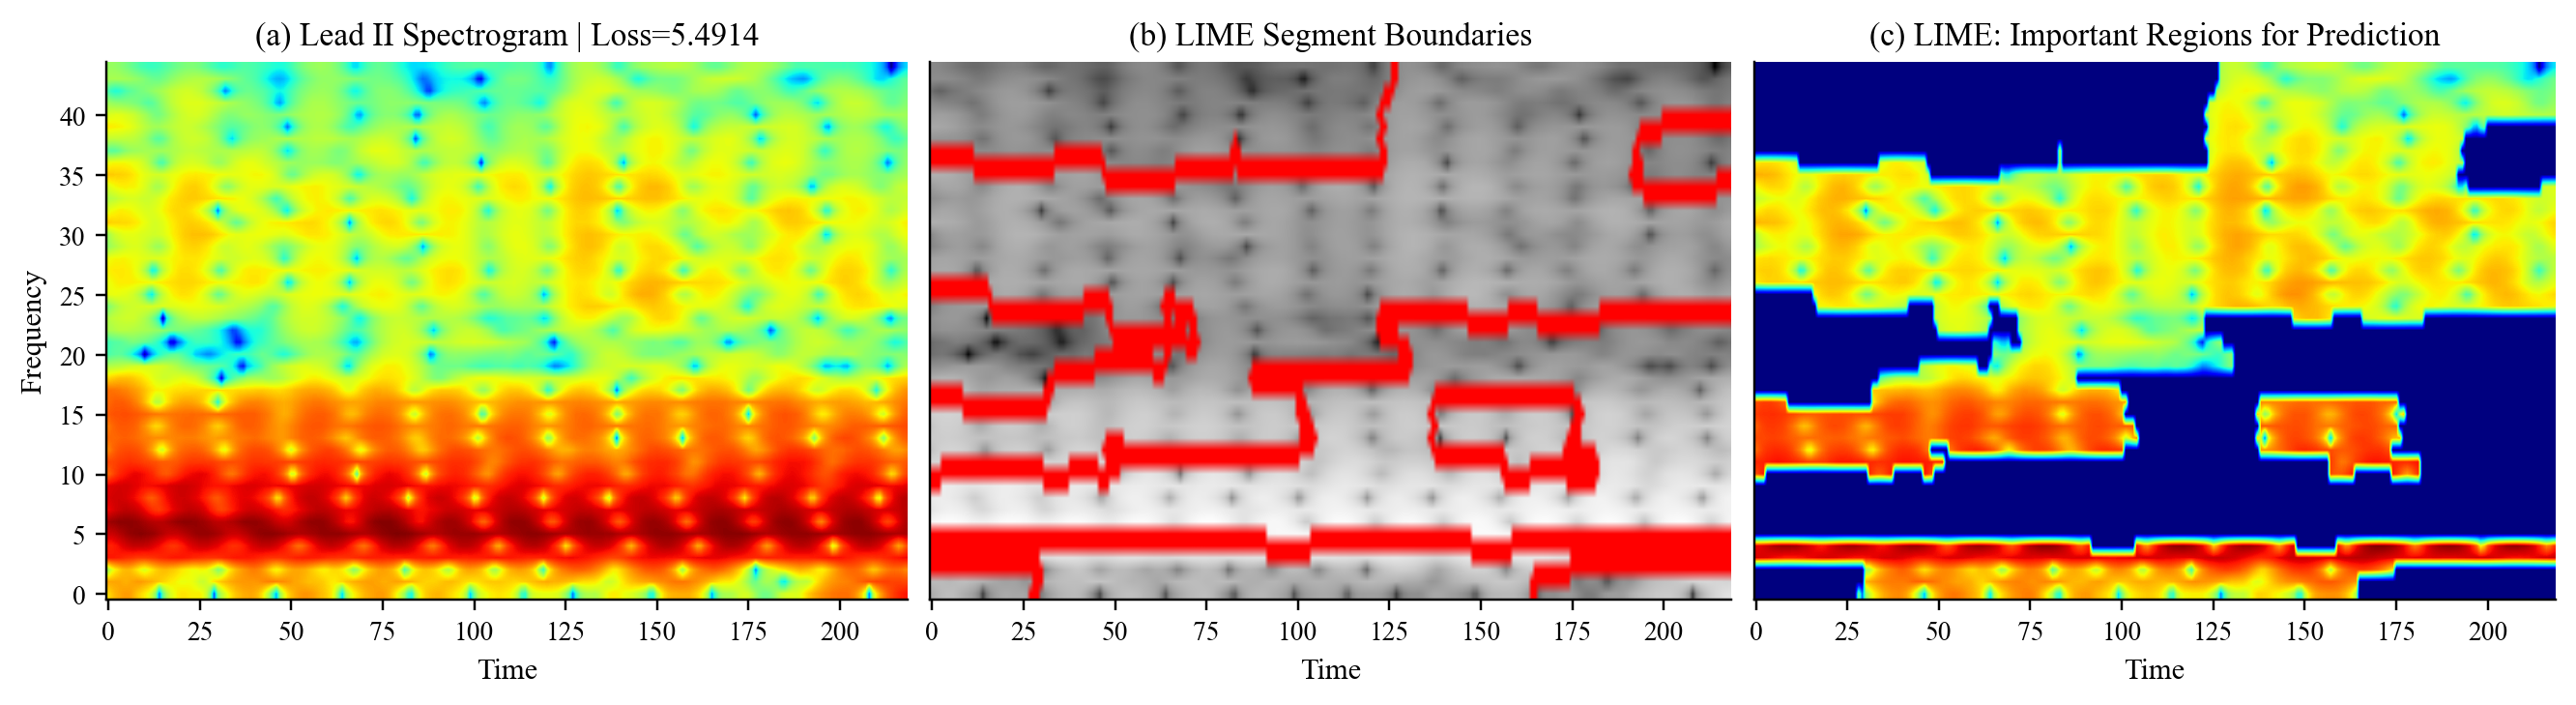

In [ ]:
from skimage.segmentation import mark_boundaries, felzenszwalb
from lime import lime_image
import warnings
warnings.filterwarnings('ignore')

final_cnn.eval()
criterion = nn.BCEWithLogitsLoss()
disease_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
num_instances = 5

# Minimal publication-style plotting setup
plt.rcParams.update({
    'figure.dpi': 220,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Times'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})


def to_model_input(ii_batch):
    return torch.from_numpy(np.tile(ii_batch[:, :, :, :1], (1, 1, 1, 12))).permute(0, 3, 1, 2).float().to(device)


def predict_fn(ii_images):
    with torch.no_grad():
        return torch.sigmoid(final_cnn(to_model_input(ii_images))).cpu().numpy()


def segment_ecg(image, scale=50, sigma=0.5, min_size=50):
    x = image[:, :, 0]
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return felzenszwalb(x, scale=scale, sigma=sigma, min_size=min_size)


# scoring all test samples by loss (II channel only)
ranked = []
for i in range(len(train_dataset)):
    image, target = train_dataset[i]

    if target.sum() == 0:
        continue  # skip all non-class samples

    ii = np.expand_dims(np.expand_dims(image.numpy()[1], 2), 0)  # (1, 45, 219, 1)
    with torch.no_grad():
        logits = final_cnn(to_model_input(ii))
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        logits_np = logits.cpu().numpy()[0]
        loss = criterion(logits, target.unsqueeze(0).to(device)).item()
    ranked.append((loss, i, target.numpy(), probs, logits_np, ii[0]))

ranked.sort(key=lambda x: x[0])
chosen = np.linspace(0, len(ranked) - 1, num_instances, dtype=int)
explainer = lime_image.LimeImageExplainer(verbose=False)


# 2) Explain samples from min -> max loss
for k, pos in enumerate(chosen, 1):
    loss, idx, target_vec, prob_vec, logit_vec, img_single = ranked[pos]

    true_idx = np.where(target_vec > 0.5)[0]
    pred_idx = np.where(prob_vec > 0.5)[0]
    true_names = [disease_names[j] for j in true_idx] if len(true_idx) else ['None']
    pred_names = [disease_names[j] for j in pred_idx] if len(pred_idx) else ['None']
    pred_class = int(np.argmax(prob_vec))  
    
    print(f"\n{'='*70}")
    print(f"Sample {k}/{num_instances} | Dataset idx={idx} | Loss={loss:.4f}")
    print(f"True classes (target>0.5): {true_names}")
    print(f"Pred classes (prob>0.5)  : {pred_names}")
    print(f"Target vector            : {np.round(target_vec, 4)}")
    print(f"Probability vector       : {np.round(prob_vec, 4)}")
    print(f"{'='*70}")

    exp = explainer.explain_instance(
        img_single,
        predict_fn,
        top_labels=5,
        hide_color=0,
        num_samples=1000,
        batch_size=64,
        segmentation_fn=segment_ecg
    )

    _, mask = exp.get_image_and_mask(pred_class, positive_only=True, num_features=10, hide_rest=False)

    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.2), constrained_layout=True)
    orig = img_single[:, :, 0]

    # Panel A: Original II-channel spectrogram
    axes[0].imshow(orig, origin='lower', cmap='jet', interpolation='bilinear', aspect='auto')
    axes[0].set_title(f'(a) Lead II Spectrogram | Loss={loss:.4f}')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Frequency')


    # Panel B: Boundary map
    n = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)
    axes[1].imshow(mark_boundaries(n, mask, color=(1, 0, 0), mode='thin'), origin='lower', aspect='auto', interpolation='bilinear')
    axes[1].set_title('(b) LIME Segment Boundaries')
    axes[1].set_xlabel('Time')
    axes[1].set_yticks([])


    # Panel C: LIME highlighted regions
    hm = orig.copy()
    hm[mask == 0] = 0
    im = axes[2].imshow(hm, origin='lower', cmap='jet', interpolation='bilinear', aspect='auto')
    axes[2].set_title(f'(c) LIME: Important Regions for Prediction')
    axes[2].set_xlabel('Time')
    axes[2].set_yticks([])

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.show()
